# Phase 5 - IFN-b Differential Expression

Central biological question: how does IFN-b stimulation alter transcriptional
programs across different PBMC cell populations? For each cell type, we
compare stimulated vs. control cells and check whether known
interferon-stimulated genes (ISGs) are recovered.

Note: UMAP visualization was skipped in this environment due to a
package-level conflict (torch/sympy) affecting UMAP's numba-based backend;
clustering (Leiden) and differential expression do not depend on UMAP and
are unaffected.

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

adata = sc.read_h5ad("../results/adata_annotated.h5ad")
print(adata.obs.groupby(["proposed_cell_type", "label"]).size().unstack())

label               ctrl  stim
proposed_cell_type            
B cells             1313  1329
CD4 T cells         5390  5433
CD14+ Monocytes     3065  2803
Dendritic cells       41   245
FCGR3A+ Monocytes    602   551
Megakaryocytes       155   171
NK cells            1695  1769


In [2]:
canonical_isgs = ["ISG15", "IFI6", "MX1", "OAS1", "IFIT1", "IFIT3", "STAT1", "IRF7", "IFITM3", "RSAD2"]
canonical_isgs_present = [g for g in canonical_isgs if g in adata.var_names]
print(f"{len(canonical_isgs_present)} of {len(canonical_isgs)} canonical ISGs found")
print(canonical_isgs_present)

10 of 10 canonical ISGs found
['ISG15', 'IFI6', 'MX1', 'OAS1', 'IFIT1', 'IFIT3', 'STAT1', 'IRF7', 'IFITM3', 'RSAD2']


In [3]:
cell_types = adata.obs["proposed_cell_type"].unique()
de_results = {}
MIN_CELLS = 30

for ct in cell_types:
    sub = adata[adata.obs["proposed_cell_type"] == ct].copy()
    n_ctrl = (sub.obs["label"] == "ctrl").sum()
    n_stim = (sub.obs["label"] == "stim").sum()
    if n_ctrl < MIN_CELLS or n_stim < MIN_CELLS:
        print(f"Skipping {ct}: insufficient cells")
        continue
    sc.tl.rank_genes_groups(sub, groupby="label", groups=["stim"], reference="ctrl", method="wilcoxon")
    result = sc.get.rank_genes_groups_df(sub, group="stim").set_index("names")
    de_results[ct] = result
    n_sig = (result["pvals_adj"] < 0.05).sum()
    print(f"{ct}: ctrl={n_ctrl}, stim={n_stim}, {n_sig} genes significant")

CD14+ Monocytes: ctrl=3065, stim=2803, 1805 genes significant


CD4 T cells: ctrl=5390, stim=5433, 566 genes significant


Dendritic cells: ctrl=41, stim=245, 418 genes significant


NK cells: ctrl=1695, stim=1769, 357 genes significant


B cells: ctrl=1313, stim=1329, 442 genes significant


Megakaryocytes: ctrl=155, stim=171, 76 genes significant


FCGR3A+ Monocytes: ctrl=602, stim=551, 846 genes significant


In [4]:
isg_summary = pd.DataFrame(index=canonical_isgs_present, columns=list(de_results.keys()))
for ct, result in de_results.items():
    for gene in canonical_isgs_present:
        if gene in result.index:
            lfc = result.loc[gene, "logfoldchanges"]
            padj = result.loc[gene, "pvals_adj"]
            isg_summary.loc[gene, ct] = f"{lfc:.2f} (p={padj:.1e})"
        else:
            isg_summary.loc[gene, ct] = "n/a"
isg_summary

,CD14+ Monocytes,CD4 T cells,Dendritic cells,NK cells,B cells,Megakaryocytes,FCGR3A+ Monocytes
ISG15,8.81 (p=0.0e+00),6.59 (p=0.0e+00),8.46 (p=5.0e-20),6.19 (p=0.0e+00),7.27 (p=0.0e+00),6.80 (p=9.5e-44),7.24 (p=2.4e-184)
IFI6,5.33 (p=0.0e+00),7.00 (p=0.0e+00),7.06 (p=5.4e-20),6.74 (p=0.0e+00),7.04 (p=0.0e+00),6.53 (p=1.5e-33),4.56 (p=1.8e-171)
MX1,6.30 (p=0.0e+00),5.58 (p=0.0e+00),5.51 (p=5.9e-20),5.56 (p=3.3e-289),5.87 (p=1.1e-278),6.28 (p=1.1e-26),5.45 (p=5.8e-158)
OAS1,5.36 (p=0.0e+00),5.63 (p=0.0e+00),6.40 (p=7.8e-19),5.46 (p=2.6e-182),5.12 (p=5.0e-121),5.38 (p=2.0e-13),3.07 (p=2.3e-122)
IFIT1,8.84 (p=0.0e+00),7.98 (p=0.0e+00),7.65 (p=7.7e-18),7.00 (p=0.0e+00),7.85 (p=4.1e-295),6.48 (p=4.5e-31),7.90 (p=4.5e-182)
IFIT3,8.30 (p=0.0e+00),8.38 (p=0.0e+00),8.28 (p=6.6e-20),6.88 (p=0.0e+00),8.28 (p=0.0e+00),6.27 (p=8.6e-28),5.77 (p=6.8e-178)
STAT1,2.00 (p=1.6e-89),4.32 (p=1.2e-186),2.96 (p=1.1e-06),3.71 (p=1.8e-17),3.07 (p=1.3e-26),3.62 (p=7.6e-06),1.14 (p=3.8e-07)
IRF7,3.77 (p=0.0e+00),3.92 (p=0.0e+00),2.93 (p=7.8e-12),3.93 (p=6.2e-151),4.62 (p=1.4e-210),4.28 (p=1.8e-10),3.81 (p=3.3e-150)
IFITM3,6.48 (p=0.0e+00),4.46 (p=9.8e-114),7.31 (p=2.5e-14),4.26 (p=6.2e-59),6.09 (p=9.1e-70),3.49 (p=7.1e-04),4.34 (p=8.1e-181)
RSAD2,8.56 (p=0.0e+00),7.08 (p=0.0e+00),8.26 (p=2.1e-16),5.66 (p=1.4e-92),7.27 (p=8.6e-63),5.25 (p=1.5e-07),6.33 (p=5.8e-158)


In [5]:
top_up_genes = {}
for ct, result in de_results.items():
    sig_up = result[(result["pvals_adj"] < 0.05) & (result["logfoldchanges"] > 1)].sort_values("pvals_adj").head(50)
    top_up_genes[ct] = set(sig_up.index)
    print(f"{ct}: {len(sig_up)} genes (adj p<0.05, logFC>1)")

from functools import reduce
shared_across_all = reduce(lambda a, b: a & b, top_up_genes.values())
print(f"\nShared across ALL cell types ({len(shared_across_all)}): {sorted(shared_across_all)}")

CD14+ Monocytes: 50 genes (adj p<0.05, logFC>1)
CD4 T cells: 50 genes (adj p<0.05, logFC>1)
Dendritic cells: 50 genes (adj p<0.05, logFC>1)
NK cells: 50 genes (adj p<0.05, logFC>1)
B cells: 50 genes (adj p<0.05, logFC>1)
Megakaryocytes: 50 genes (adj p<0.05, logFC>1)
FCGR3A+ Monocytes: 50 genes (adj p<0.05, logFC>1)

Shared across ALL cell types (26): ['BST2', 'EPSTI1', 'HERC5', 'IFI35', 'IFI44L', 'IFI6', 'IFIT1', 'IFIT2', 'IFIT3', 'IFITM3', 'IRF7', 'ISG15', 'ISG20', 'LY6E', 'MX1', 'MX2', 'OAS1', 'OASL', 'PLSCR1', 'PSMB9', 'RSAD2', 'SAMD9L', 'SAT1', 'TMSB10', 'TNFSF10', 'UBE2L6']


CD14+ Monocytes      1805
FCGR3A+ Monocytes     846
CD4 T cells           566
B cells               442
Dendritic cells       418
NK cells              357
Megakaryocytes         76
dtype: int64


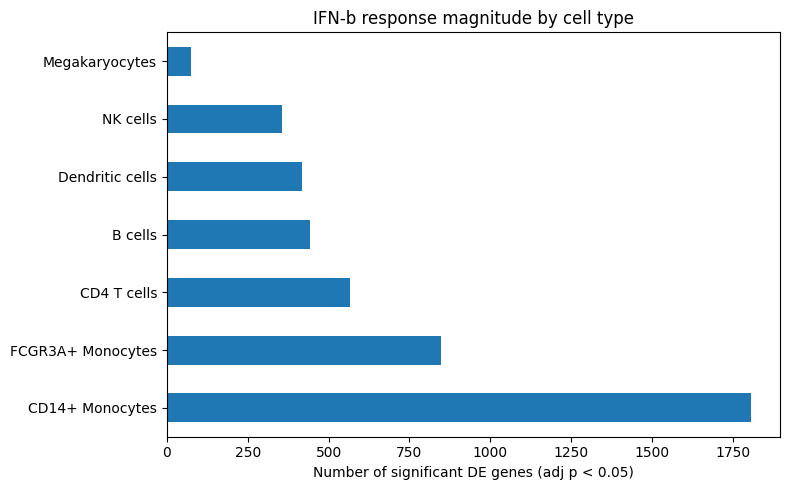

In [6]:
response_magnitude = pd.Series({ct: (r["pvals_adj"] < 0.05).sum() for ct, r in de_results.items()}).sort_values(ascending=False)
print(response_magnitude)

fig, ax = plt.subplots(figsize=(8, 5))
response_magnitude.plot(kind="barh", ax=ax)
ax.set_xlabel("Number of significant DE genes (adj p < 0.05)")
ax.set_title("IFN-b response magnitude by cell type")
plt.tight_layout()
plt.savefig("../figures/fig3a_response_magnitude.png", dpi=150, bbox_inches="tight")
plt.show()

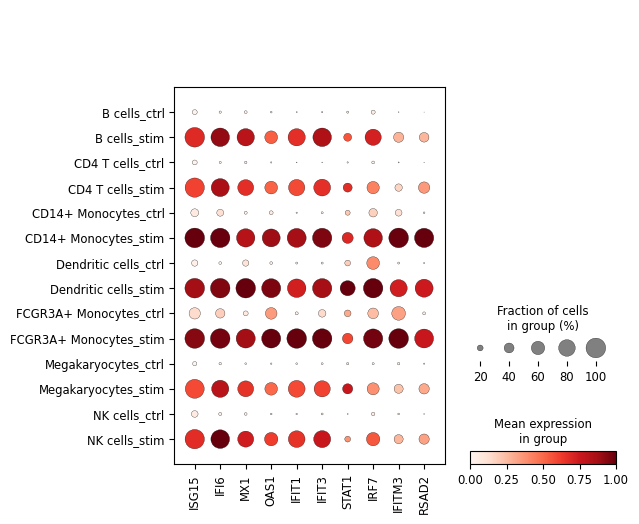

<Figure size 640x480 with 0 Axes>

In [7]:
adata.obs["cell_type_condition"] = adata.obs["proposed_cell_type"].astype(str) + "_" + adata.obs["label"].astype(str)
sc.pl.dotplot(adata, canonical_isgs_present, groupby="cell_type_condition", standard_scale="var")
plt.savefig("../figures/fig3b_isg_dotplot.png", dpi=150, bbox_inches="tight")
plt.show()

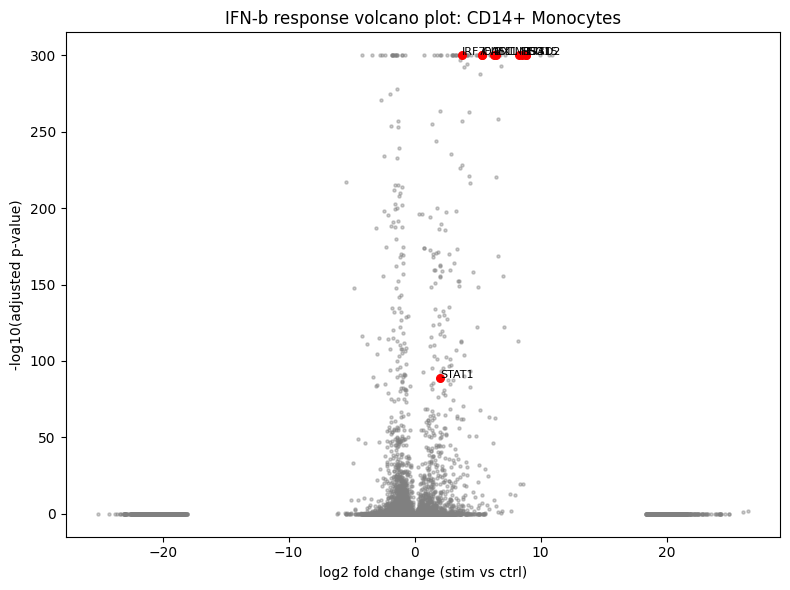

In [8]:
strongest_ct = response_magnitude.index[0]
result = de_results[strongest_ct].copy()
result["neg_log10_padj"] = -np.log10(result["pvals_adj"].clip(lower=1e-300))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(result["logfoldchanges"], result["neg_log10_padj"], s=5, alpha=0.4, color="gray")
highlight = result.loc[result.index.isin(canonical_isgs_present)]
ax.scatter(highlight["logfoldchanges"], highlight["neg_log10_padj"], s=30, color="red")
for gene, row in highlight.iterrows():
    ax.annotate(gene, (row["logfoldchanges"], row["neg_log10_padj"]), fontsize=8)
ax.set_xlabel("log2 fold change (stim vs ctrl)")
ax.set_ylabel("-log10(adjusted p-value)")
ax.set_title(f"IFN-b response volcano plot: {strongest_ct}")
plt.tight_layout()
plt.savefig("../figures/fig3c_volcano.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
import os
os.makedirs("../results", exist_ok=True)
for ct, result in de_results.items():
    safe_name = ct.replace(" ", "_").replace("+", "plus")
    result.to_csv(f"../results/de_{safe_name}.csv")
isg_summary.to_csv("../results/isg_summary_by_celltype.csv")
response_magnitude.to_csv("../results/response_magnitude_by_celltype.csv")
print("Saved all Phase 5 results")

Saved all Phase 5 results
